# Семинар

1. Загрузить прилагающийся к работе датасет PRSA_Data
2. Выведите на экран основную информацию о датасете. Идентифицируйте значения вне разумного диапазона
3. Постройте визуализацию распределения каждого численного атрибута.
4. Исходя из распределения атрибутов по необходимости примените бинаризацию численных признаков.
5. Постройте совместное распределение каждого признака вместе с целевой переменной. Сделайте вывод о необходимости проведения группировки данных.
6. Удалите или ограничьте экстремальные значения атрибутов.
7. Избавьтесь от пропущенных значений в датасете.
8. При необходимости округлите излишне точные значения атрибутов.
9. Рассмотрите возможность преобразования шкалы атрибута к логарифмической.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
prsa_data = pd.read_csv("PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


In [ ]:
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  object 
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  object 
dtypes: float64(7), int64(2), object(2)
memory usage: 2.9+ MB


In [ ]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


In [ ]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


<Axes: xlabel='SO2', ylabel='Count'>

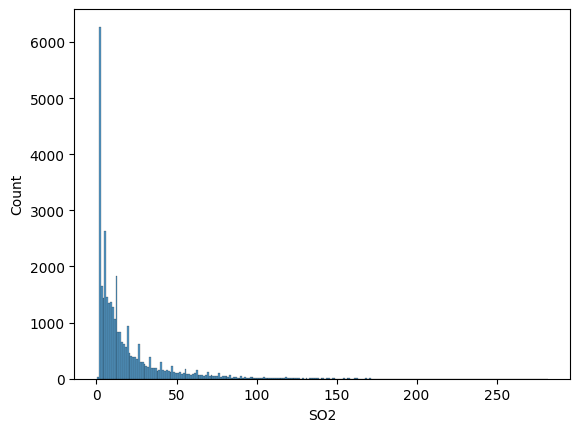

In [ ]:
sns.histplot(prsa_data.SO2)

<Axes: xlabel='NO2', ylabel='Density'>

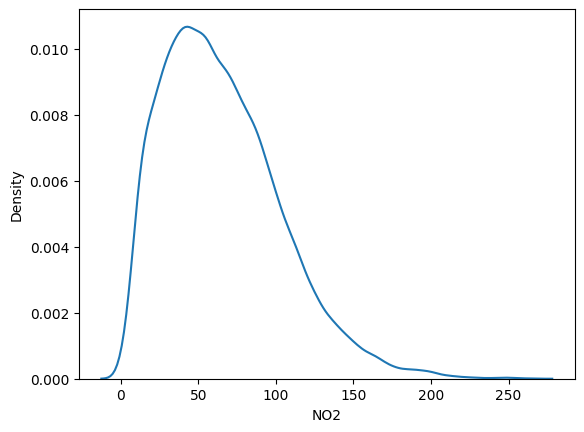

In [ ]:
sns.kdeplot(prsa_data.NO2)

In [ ]:
prsa_data.RAIN[prsa_data.RAIN > 0]

,RAIN
267,0.1
268,0.4
269,0.1
270,0.9
271,0.9
...,...
34891,0.2
34892,0.7
34893,0.9
34894,0.4


In [ ]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


<Axes: xlabel='SO2', ylabel='Density'>

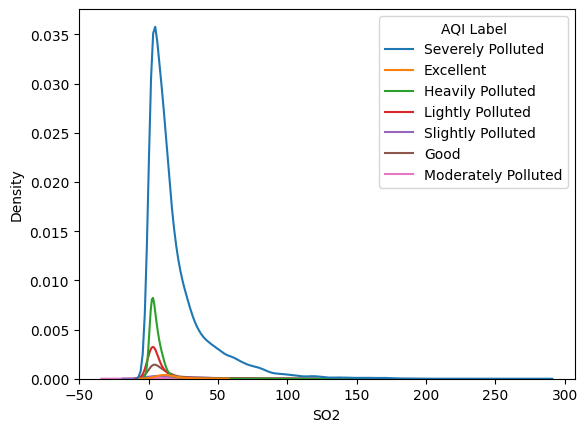

In [ ]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

<ipython-input-140-c5b2a0db864b>:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

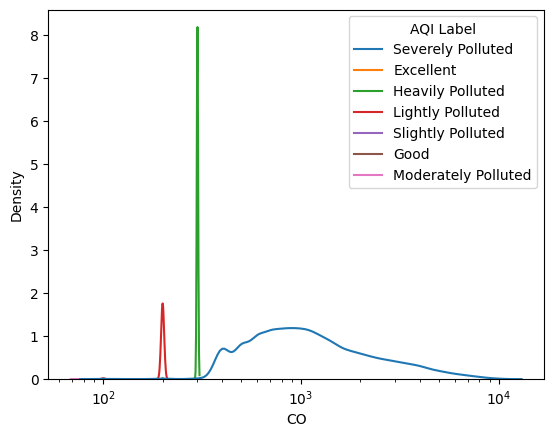

In [ ]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

In [ ]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']),
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [ ]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [ ]:
prsa_data.PRES[prsa_data.PRES <= 992] = 992
prsa_data.PRES[prsa_data.PRES >= 1034] = 1034

<ipython-input-143-5a60bf876b2e>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  prsa_data.PRES[prsa_data.PRES <= 992] = 992
<ipython-input-143-5a60bf876b2e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

<Axes: >

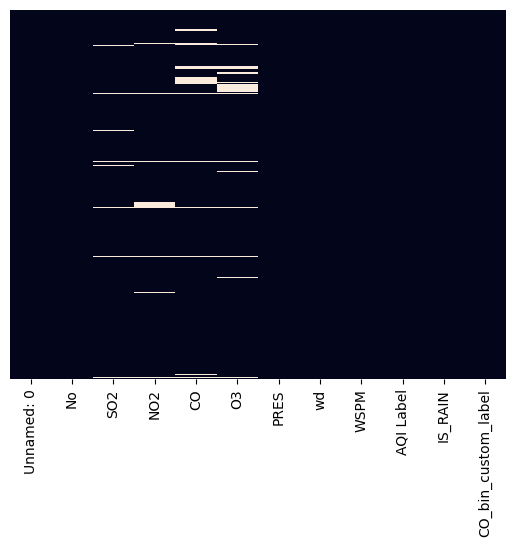

In [ ]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [ ]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

,0
3,2
276,3
435,2
459,2
555,2
...,...
34880,4
34883,4
34885,4
35029,2


In [ ]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

In [ ]:
prsa_data.isnull().sum()

,0
Unnamed: 0,0
No,0
SO2,281
NO2,702
CO,1028
O3,1300
PRES,0
wd,0
WSPM,0
AQI Label,0


In [ ]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())

In [ ]:
filler = prsa_data.O3[prsa_data.O3.isna()]

In [ ]:
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)

In [ ]:
prsa_data.O3 = prsa_data.O3.fillna(filler)

In [ ]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.000000,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.000000,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,1011.055986,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.000000,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.000000,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


In [ ]:
prsa_data.SO2 = np.log(prsa_data.SO2)

# Задания для самостоятельного выполнения

1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.
2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.
3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.
4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.
5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.
6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.

## 1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.

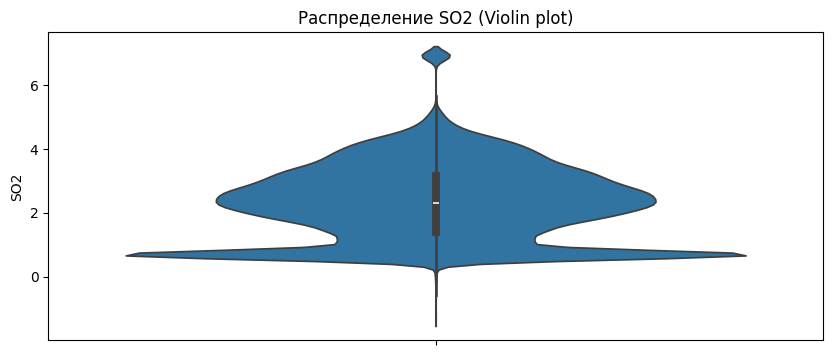

In [ ]:
plt.figure(figsize=(10, 4))
sns.violinplot(data=prsa_data, y='SO2')
plt.title('Распределение SO2 (Violin plot)')
plt.show()

- Большая часть значений SO2 сосредоточена около 0–2 единиц.
- Есть длинный "хвост" с редкими высокими значениями (до 8), что указывает на выбросы.

показывает, медиану, квартили, форму распределения.

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


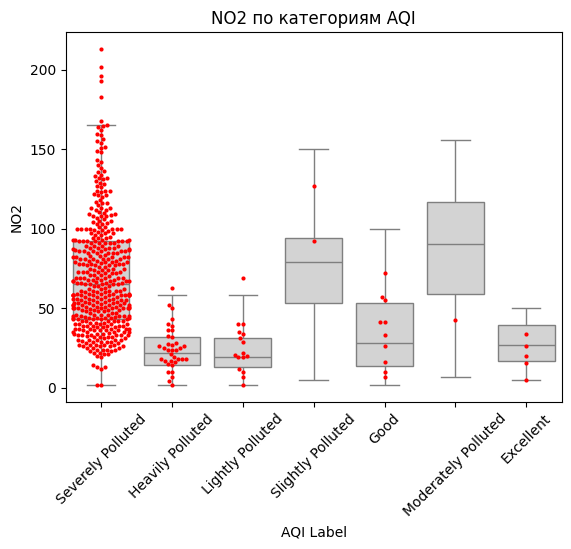

In [ ]:
sns.boxplot(data=prsa_data, x='AQI Label', y='NO2', color='lightgray', showfliers=False) # убирает выбросы, чтобы график был чище.
sns.swarmplot(data=prsa_data.sample(n=500), x='AQI Label', y='NO2', size=3, color='red')

plt.title('NO2 по категориям AQI')
plt.xticks(rotation=45)
plt.show()

- Разброс значений больше в категориях с плохим качеством воздуха, что логично: загрязнение более вариативно в плохих условиях.

точки показывают плотность данных.

## 2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.



<Axes: xlabel='PRES', ylabel='Count'>

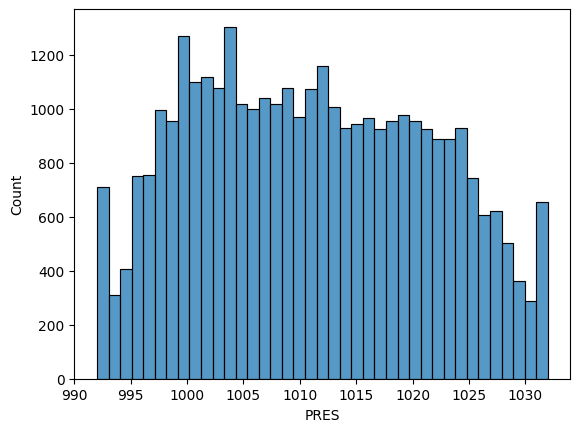

In [ ]:
def adaptive_clipping(df, column, lower_percentile=1, upper_percentile=99): # ограничивает значения в столбце
    lower_bound = df[column].quantile(lower_percentile / 100)
    upper_bound = df[column].quantile(upper_percentile / 100)
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df

prsa_data = adaptive_clipping(prsa_data, 'PRES')
sns.histplot(prsa_data['PRES'])

- Распределение выглядит почти нормальным
- Клиппинг убрал редкие экстремальные значения, которые могли бы искажать анализ.

## 3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.

In [ ]:
prsa_data['NO2'] = prsa_data['NO2'].fillna(prsa_data['NO2'].median())

используем медиану, потому что распределение относительно симметричное в каждой категории

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
prsa_data['CO'] = imputer.fit_transform(prsa_data[['CO']])

смотрим на 5 ближайших строк и заполняем пропуски средним значением из этих строк CO

In [ ]:
prsa_data['wd'] = prsa_data['wd'].fillna('Unknown')

для категориального столбца wd - направление ветра, пропуски заполняются значением unknown

## 4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# MinMax для PRES (границы известны)
prsa_data['PRES_scaled'] = MinMaxScaler().fit_transform(prsa_data[['PRES']])

# StandardScaler для NO2 (нормальное распределение)
prsa_data['NO2_scaled'] = StandardScaler().fit_transform(prsa_data[['NO2']])

# RobustScaler для SO2 (есть выбросы)
prsa_data['SO2_scaled'] = RobustScaler().fit_transform(prsa_data[['SO2']])

# Log-преобразование для CO (сильная асимметрия)
prsa_data['CO_log'] = np.log1p(prsa_data['CO'])

нормализация нужна, чтобы привести признаки к единому масштабу

## 5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.

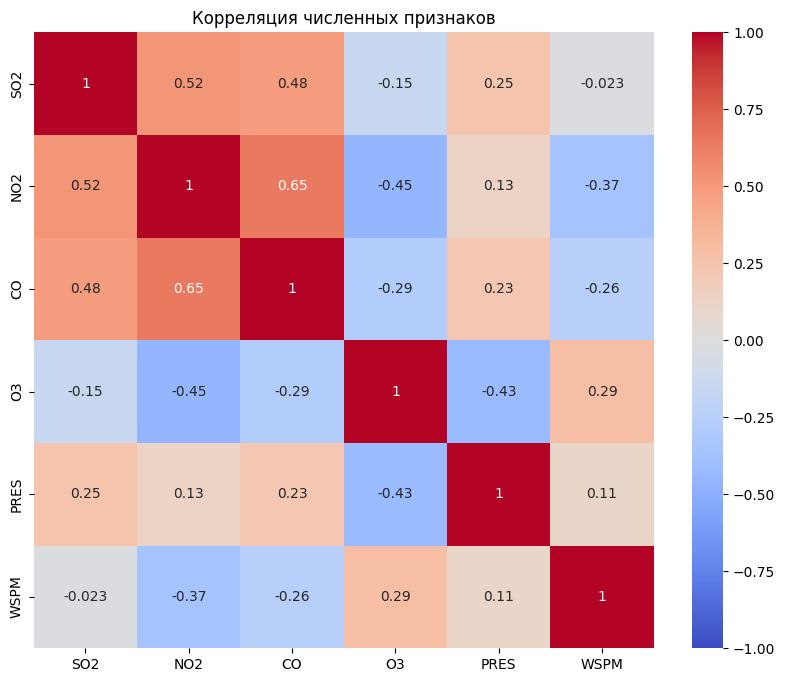

In [ ]:
numerical_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']
corr_matrix = prsa_data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция численных признаков')
plt.show()

- сильная корреляция ($>0.7$) между NO2 и CO, тогда можно объединить в один признак
- PRES слабо коррелирует с остальными, поэтому оставим как независимый фактор

## 6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.

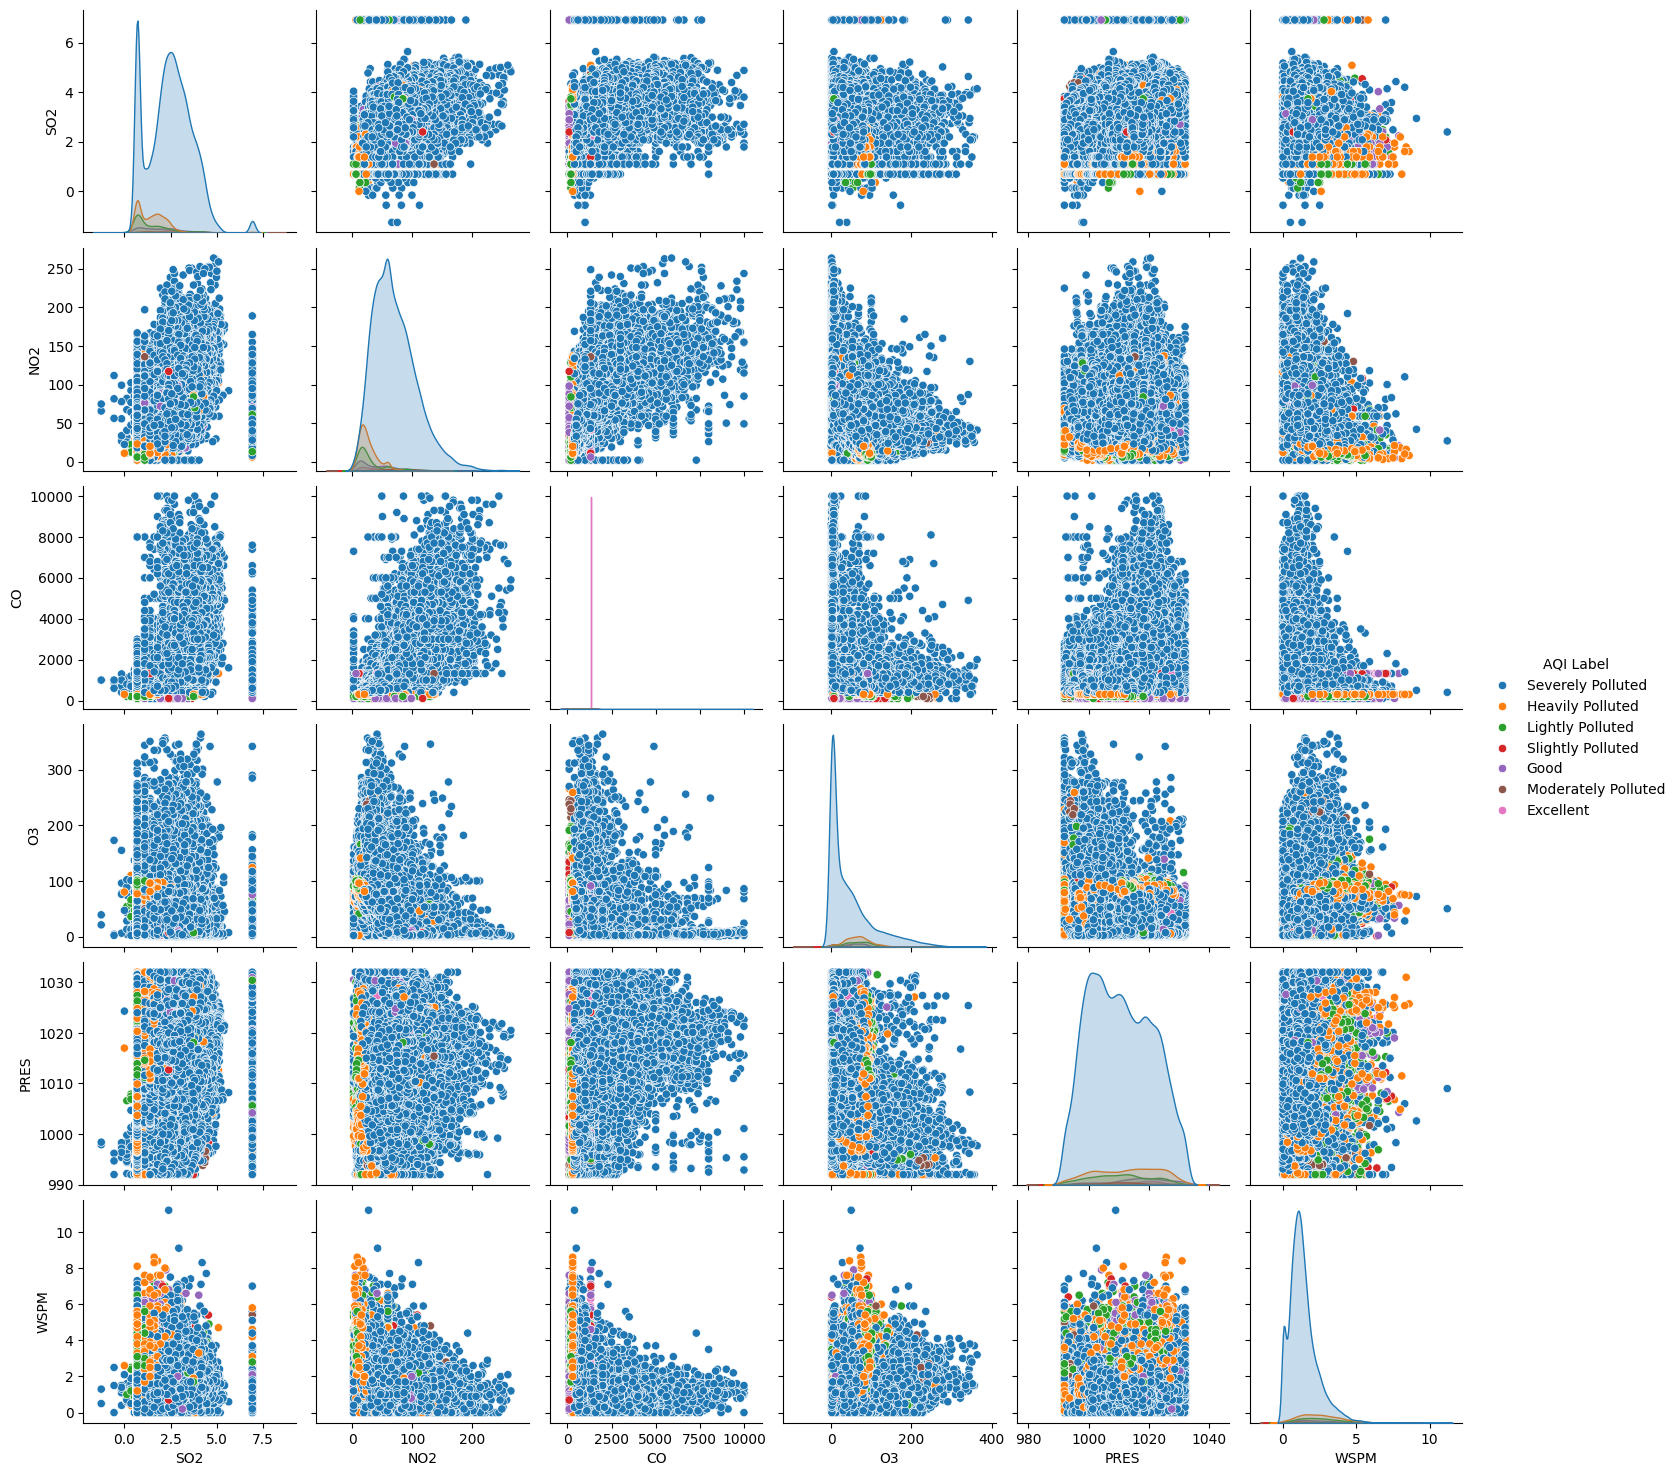

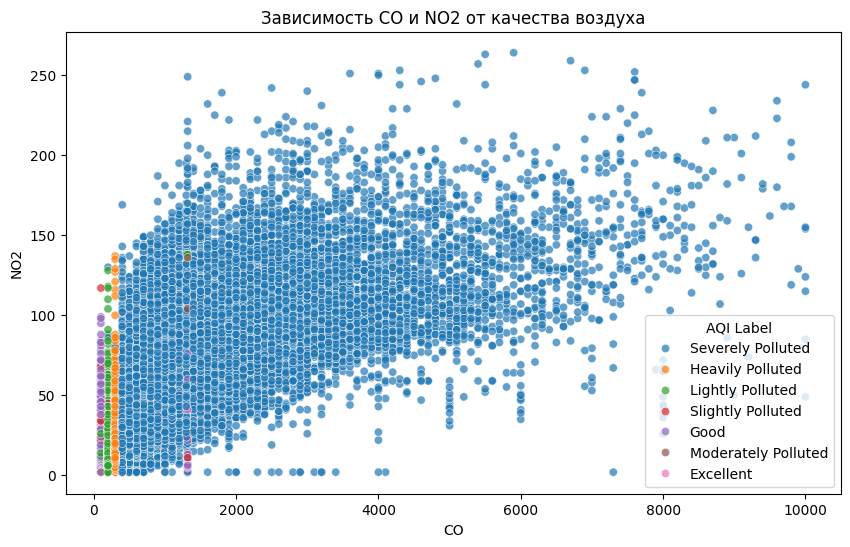

In [ ]:
# pairplot для основных признаков
sns.pairplot(prsa_data[numerical_cols + ['AQI Label']], hue='AQI Label')
plt.show()

# scatterplot для CO и NO2 с цветом по AQI
plt.figure(figsize=(10, 6))
sns.scatterplot(data=prsa_data, x='CO', y='NO2', hue='AQI Label', alpha=0.7)
plt.title('Зависимость CO и NO2 от качества воздуха')
plt.show()

- CO и NO2 линейно связаны, можно применить PCA для уменьшения размерности
- O3 слабо зависит от других газов, тогда он важен как самостоятельный признак
- качество воздуха (AQI Label) четко связано с уровнями CO и NO2: чем выше загрязнение, тем хуже категория

# Дополнительные задания

1. В данной работе проверьте целесообразность каждого необязательного преобразования данных путем проверки, увеличивает ли данное преобразование точность модели. Проверьте на простом виде модели (логит регрессия, дерево решений или случайный лес).
2. Проанализируйте эффективность использования различных методов заполнения пропущенных значений.
3. Попробуйте придумать другие методы инжиниринга признаков в этом датасете. Оцените их эффект по какой-то модели.
4. Перед началом обработки данных разбейте датасет на тестовую и обучающую выборки. Очистите по методу из работы обучающую выборку. Повторите обработку на тестовой выборке. При этом позаботьтесь, чтобы все параметрические преобразования (клиппинг, нормализация, группировка и так далее).
5. Создайте воспроизводимый код обработки данного датасета.
6. В датасете Customer_support, который стал результатом выполнения предыдущей работы преобразуйте все даты в абсолютные признаки. Извлеките из дат значимую информацию - день недели, время дня, день месяца. Составьте значимые временные промежутки.
7. Повторите обработку численных параметров в датасете "Титаник".
8. (*) Создайте код, реализующий алгоритм очистки данных автоматически (для любого датасета).

## 1. В данной работе проверьте целесообразность каждого необязательного преобразования данных путем проверки, увеличивает ли данное преобразование точность модели. Проверьте на простом виде модели (логит регрессия, дерево решений или случайный лес).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X = prsa_data.drop('AQI Label', axis=1)
y = prsa_data['AQI Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# базовая модель (без преобразований)
model = RandomForestClassifier(random_state=42)
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

model.fit(X_train_numeric, y_train)
base_accuracy = accuracy_score(y_test, model.predict(X_test_numeric))
print(f"Accuracy до преобразований: {base_accuracy:.3f}")

Accuracy до преобразований: 0.986


In [ ]:
# модель с логарифмированием SO2
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# применяем логарифмическое преобразование к SO2 в обеих выборках
# и используем np.log1p, чтобы избежать проблем с нулевыми значениями
X_train_log['SO2'] = np.log1p(X_train_log['SO2'])
X_test_log['SO2'] = np.log1p(X_test_log['SO2'])

X_train_log_numeric = X_train_log.select_dtypes(include=['number'])
X_test_log_numeric = X_test_log.select_dtypes(include=['number'])

model.fit(X_train_log_numeric, y_train)
log_accuracy = accuracy_score(y_test, model.predict(X_test_log_numeric))
print(f"Accuracy после логарифмирования SO2: {log_accuracy:.3f}")

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Accuracy после логарифмирования SO2: 0.986


In [ ]:
if log_accuracy > base_accuracy:
    print("Логарифмирование SO2 улучшило точность модели на {:.3f}".format(log_accuracy - base_accuracy))
elif log_accuracy < base_accuracy:
    print("Логарифмирование SO2 ухудшило точность модели на {:.3f}".format(base_accuracy - log_accuracy))
else:
    print("Логарифмирование SO2 не повлияло на точность модели")

Логарифмирование SO2 не повлияло на точность модели


## 2. Проанализируйте эффективность использования различных методов заполнения пропущенных значений.

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# разделение признаков на числовые и категориальные
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# создаем трансформеры для числовых и категориальных признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # медиана для чисел
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # мода для категорий
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Объединяем
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model.fit(X_train_processed, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test_processed)))

Accuracy: 0.9862492685781159


## 3. Попробуйте придумать другие методы инжиниринга признаков в этом датасете. Оцените их эффект по какой-то модели.

In [ ]:
# создаем новый признак выборках
X_train['CO_NO2_ratio'] = X_train['CO'] / (X_train['NO2'] + 1e-6)  # чтобы избежать деления на 0
X_test['CO_NO2_ratio'] = X_test['CO'] / (X_test['NO2'] + 1e-6)     # тот же признак в test!

print("Признаки в X_train:", X_train.columns.tolist())

model.fit(X_train[['CO', 'NO2', 'CO_NO2_ratio']], y_train)
accuracy = accuracy_score(y_test, model.predict(X_test[['CO', 'NO2', 'CO_NO2_ratio']]))
print(f"Accuracy с новым признаком: {accuracy:.3f}")

Признаки в X_train: ['Unnamed: 0', 'No', 'SO2', 'NO2', 'CO', 'O3', 'PRES', 'wd', 'WSPM', 'IS_RAIN', 'CO_bin_custom_label', 'PRES_scaled', 'NO2_scaled', 'SO2_scaled', 'CO_log', 'CO_NO2_ratio']
Accuracy с новым признаком: 0.977


## 4. Перед началом обработки данных разбейте датасет на тестовую и обучающую выборки. Очистите по методу из работы обучающую выборку. Повторите обработку на тестовой выборке. При этом позаботьтесь, чтобы все параметрические преобразования (клиппинг, нормализация, группировка и так далее).

In [ ]:
# разделение до обработки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# обучение нормализатора на train
scaler = StandardScaler().fit(X_train[['SO2']])
X_train['SO2'] = scaler.transform(X_train[['SO2']])
X_test['SO2'] = scaler.transform(X_test[['SO2']])

## 5. Создайте воспроизводимый код обработки данного датасета.

In [ ]:
def load_and_preprocess(path):
    data = pd.read_csv(path)
    data.replace(-1, np.nan, inplace=True)

    # заполнение пропусков
    data['SO2'] = data['SO2'].fillna(data['SO2'].median())

    # логарифмирование
    data['SO2_log'] = np.log1p(data['SO2'])

    # разделение данных
    X = data.drop('AQI Label', axis=1)
    y = data['AQI Label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    return X_train, X_test, y_train, y_test

## 6. В датасете Customer_support, который стал результатом выполнения предыдущей работы преобразуйте все даты в абсолютные признаки. Извлеките из дат значимую информацию - день недели, время дня, день месяца. Составьте значимые временные промежутки.


In [ ]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv("Customer_support_data.csv")

# Функция для преобразования дат
def convert_date(date_str):
    try:
        # Основной формат: 'день/месяц/год час:минута'
        return pd.to_datetime(date_str, format='%d/%m/%Y %H:%M', dayfirst=True)
    except:
        try:
            # Альтернативный формат (если есть)
            return pd.to_datetime(date_str, format='%d-%b-%y', dayfirst=True)
        except:
            return pd.NaT

# Применяем ко всем столбцам с датами
date_columns = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in date_columns:
    df[col] = df[col].apply(convert_date)

    # Проверяем количество неудачных преобразований
    failed = df[col].isna().sum()
    print(f"В столбце {col} не преобразовано {failed} значений")

# Создаем временные признаки только для успешных преобразований
for col in date_columns:
    valid_mask = df[col].notna()

    # День недели (0-пн, 6-вс)
    df.loc[valid_mask, f'{col}_day_of_week'] = df.loc[valid_mask, col].dt.dayofweek

    # Час дня
    df.loc[valid_mask, f'{col}_hour'] = df.loc[valid_mask, col].dt.hour

    # Выходной день
    df.loc[valid_mask, f'{col}_is_weekend'] = df.loc[valid_mask, f'{col}_day_of_week'].isin([5,6]).astype(int)

    # Время суток
    bins = [0, 6, 12, 18, 24]
    labels = ['Ночь', 'Утро', 'День', 'Вечер']
    df.loc[valid_mask, f'{col}_time_of_day'] = pd.cut(
        df.loc[valid_mask, f'{col}_hour'],
        bins=bins,
        labels=labels,
        right=False
    )

# Сохраняем результат
df.to_csv('Customer_support_processed.csv', index=False)

В столбце order_date_time не преобразовано 68693 значений
В столбце Issue_reported at не преобразовано 0 значений
В столбце issue_responded не преобразовано 0 значений
В столбце Survey_response_Date не преобразовано 0 значений


In [ ]:
problem_dates = df.loc[df['order_date_time'].isna(), 'order_date_time'].unique()
print("Примеры проблемных значений:", problem_dates[:20])

Примеры проблемных значений: <DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]


In [ ]:
print("Статистика по преобразованным датам:")
print(f"Всего строк: {len(df)}")
print(f"Успешно преобразовано: {df['order_date_time'].notna().sum()}")
print("\nПримеры данных:")
print(df[['order_date_time', 'order_date_time_hour', 'order_date_time_time_of_day']].head())

Статистика по преобразованным датам:
Всего строк: 85907
Успешно преобразовано: 17214

Примеры данных:
  order_date_time  order_date_time_hour order_date_time_time_of_day
0             NaT                   NaN                         NaN
1             NaT                   NaN                         NaN
2             NaT                   NaN                         NaN
3             NaT                   NaN                         NaN
4             NaT                   NaN                         NaN


не получилось

## 7. Повторите обработку численных параметров в датасете "Титаник".

In [ ]:
titanic = pd.read_csv('titanic.csv')

# заполнение пропусков
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())

# удаление столбцов
titanic.drop('Cabin', axis=1, inplace=True, errors='ignore')

In [ ]:
# создание возрастных групп
bins = [0, 18, 30, 50, 100]
labels = ['Child', 'Young', 'Adult', 'Senior']
titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

# нормализация
scaler = StandardScaler()
titanic[['age_scaled', 'fare_scaled']] = scaler.fit_transform(titanic[['Age', 'Fare']])

Text(0, 0.5, 'Количество пассажиров')

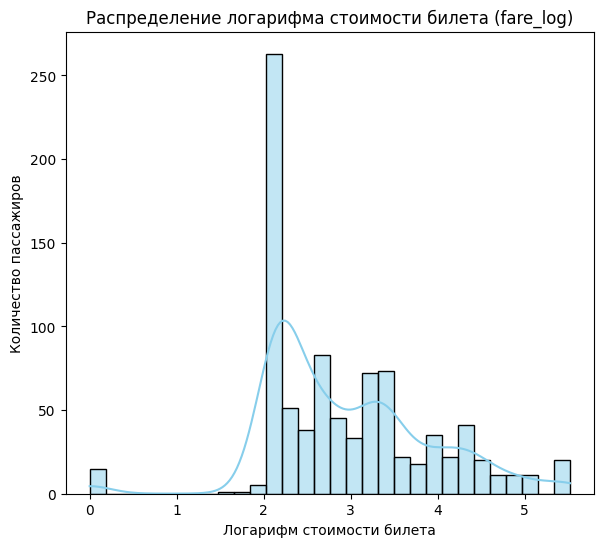

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(titanic['fare_log'], kde=True, bins=30, color='skyblue')
plt.title('Распределение логарифма стоимости билета (fare_log)')
plt.xlabel('Логарифм стоимости билета')
plt.ylabel('Количество пассажиров')

<ipython-input-193-7dd715f7b1d2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='Fare', data=titanic, palette='pastel')


Text(0, 0.5, 'Стоимость билета')

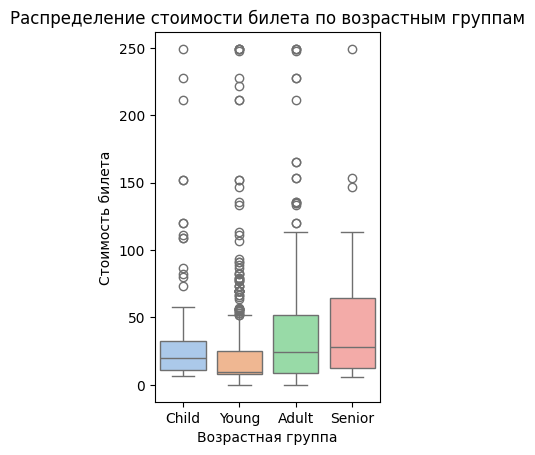

In [ ]:
plt.subplot(1, 2, 2)
sns.boxplot(x='age_group', y='Fare', data=titanic, palette='pastel')
plt.title('Распределение стоимости билета по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Стоимость билета')